<a href="https://colab.research.google.com/github/Linn-ds/DataScienceJourney/blob/main/ai_job_impact.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI Job Impact Analysis

### 📌 Project Overview
This notebook examines the transformative impact of Artificial Intelligence (AI) adoption on the global workforce across multiple sectors, including IT, Healthcare, Finance, and Manufacturing. Utilizing a dataset comprising 2,000 individual employee records, this analysis investigates the interplay between AI adoption levels, automation risks, salary adjustments, and employee productivity. The primary objective is to yield data-driven insights into workforce displacement, the economic implications of AI integration, and actionable trends for strategic workforce planning and upskilling initiatives.

### 🔍 Key Questions Addressed
*   **Workforce Risk:** Which industries and specific job roles confront the highest risk of automation?
*   **Financial Impact:** Does the integration of AI lead to statistically significant changes in employee salaries?
*   **Efficiency Gains:** How do distinct levels of AI adoption (Low, Medium, High) influence overall employee productivity?

### 🛠️ Methodology & Statistical Framework
To advance beyond basic descriptive summaries, this notebook employs rigorous hypothesis testing to validate observed trends:
*   **Data Preprocessing & EDA:** Involves the removal of unique identifiers, engineering of a percentage salary change metric (`%change_in_salary`), and encoding of categorical variables.
*   **Salary Transformation Analysis (Paired t-test):** Tests the hypothesis that salaries undergo a statistically significant shift post-AI implementation ($\\mu_{\\text{After AI}} \\neq \\mu_{\\text{Before AI}}$).
*   **Productivity Variance Analysis (ANOVA & Tukey's HSD):** Employs an ANOVA test to ascertain if productivity changes vary significantly across AI adoption tiers, subsequently utilizing a Tukey Honestly Significant Difference (HSD) post-hoc test to identify specific pairwise differences among adoption groups contributing to the observed variance.

### 🔍 Key Questions Addressed
*   **Workforce Risk:** Which industries and specific job roles face the highest risk of automation?
*   **Financial Impact:** Does the integration of AI lead to statistically significant changes in employee salaries?
*   **Efficiency Gains:** How do different levels of AI adoption (Low, Medium, High) impact overall employee productivity?

### 🛠️ Methodology & Statistical Framework
To move beyond basic descriptive summaries, this notebook utilizes rigorous hypothesis testing to validate trends:
*   **Data Preprocessing & EDA:** Dropping structural identifiers, engineering a percentage salary change metric (`%change_in_salary`), and encoding categorical segments.
*   **Salary Transformation Analysis (Paired t-test):** Testing the hypothesis that salaries shift significantly post-AI implementation ($\mu_{\text{After AI}} \neq \mu_{\text{Before AI}}$).
*   **Productivity Variance Analysis (ANOVA & Tukey's HSD):** Utilizing an ANOVA test to verify if productivity changes differ across AI adoption tiers, followed by a Tukey Honestly Significant Difference (HSD) post-hoc test to pinpoint exactly which adoption groups drive the variance.

### 🚀 Core Libraries Used
*   `pandas` & `numpy` — Data manipulation and feature engineering
*   `matplotlib` — Data visualization and stacked categorical profiling
*   `scipy.stats` — Paired t-testing and one-way ANOVA implementation
*   `statsmodels` — Multi-comparison post-hoc statistical testing (Tukey's HSD)

Author: [Linn Htet Aung] Date: May 2026 Dataset Source: AI Impact on Job Sector (https://www.kaggle.com/datasets/sumeakash/ai-impact-on-job-sector/data)

## 1. Setup and Data Loading

In [84]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [85]:
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/ai_job_impact/ai_job_impact.csv')

data.head()

,Employee_ID,Age,Gender,Education_Level,Industry,Job_Role,Years_Experience,AI_Adoption_Level,Automation_Risk,Upskilling_Required,Salary_Before_AI,Salary_After_AI,Job_Status,Work_Hours_Per_Week,Remote_Work,Job_Satisfaction,Productivity_Change_%
0,E0001,50,Female,Bachelor,Marketing,Content Creator,26,High,High,Yes,106820,95455,Replaced,45,No,5,-10.64
1,E0002,45,Male,High School,Manufacturing,Quality Inspector,19,Low,Low,Yes,74131,72013,Unchanged,36,Yes,6,19.05
2,E0003,51,Female,Master,IT,DevOps Engineer,28,Medium,Medium,Yes,35311,42290,Modified,46,Yes,3,17.05
3,E0004,48,Male,PhD,Education,Teacher,24,Medium,Medium,Yes,114478,107820,Modified,50,No,9,-2.47
4,E0005,24,Male,Bachelor,Healthcare,Doctor,0,High,Medium,No,33890,40945,Modified,52,Yes,6,7.03


## 2. Initial Data Exploration

In [86]:
#reading the null values
data.isnull().sum()

,0
Employee_ID,0
Age,0
Gender,0
Education_Level,0
Industry,0
Job_Role,0
Years_Experience,0
AI_Adoption_Level,0
Automation_Risk,0
Upskilling_Required,0


In [87]:
#shape

data.shape

(2000, 17)

In [88]:
data.columns

Index(['Employee_ID', 'Age', 'Gender', 'Education_Level', 'Industry',
       'Job_Role', 'Years_Experience', 'AI_Adoption_Level', 'Automation_Risk',
       'Upskilling_Required', 'Salary_Before_AI', 'Salary_After_AI',
       'Job_Status', 'Work_Hours_Per_Week', 'Remote_Work', 'Job_Satisfaction',
       'Productivity_Change_%'],
      dtype='object')

In [89]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Employee_ID            2000 non-null   object 
 1   Age                    2000 non-null   int64  
 2   Gender                 2000 non-null   object 
 3   Education_Level        2000 non-null   object 
 4   Industry               2000 non-null   object 
 5   Job_Role               2000 non-null   object 
 6   Years_Experience       2000 non-null   int64  
 7   AI_Adoption_Level      2000 non-null   object 
 8   Automation_Risk        2000 non-null   object 
 9   Upskilling_Required    2000 non-null   object 
 10  Salary_Before_AI       2000 non-null   int64  
 11  Salary_After_AI        2000 non-null   int64  
 12  Job_Status             2000 non-null   object 
 13  Work_Hours_Per_Week    2000 non-null   int64  
 14  Remote_Work            2000 non-null   object 
 15  Job_

In [90]:
data.describe()

,Age,Years_Experience,Salary_Before_AI,Salary_After_AI,Work_Hours_Per_Week,Job_Satisfaction,Productivity_Change_%
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000
mean,40.558000,16.663500,73942.072500,78428.642500,44.85100,6.020500,9.785820
std,10.786418,10.746675,26055.823793,29351.599013,5.71254,2.006263,17.187882
min,22.000000,0.000000,30036.000000,24447.000000,35.00000,3.000000,-19.990000
25%,32.000000,8.000000,51665.500000,54086.750000,40.00000,4.000000,-5.355000
50%,40.000000,16.000000,74620.000000,76820.500000,45.00000,6.000000,9.850000
75%,50.000000,26.000000,95418.250000,100730.250000,50.00000,8.000000,24.582500
max,59.000000,37.000000,119976.000000,161745.000000,54.00000,9.000000,39.990000


In [91]:
data.describe(include='object')

,Employee_ID,Gender,Education_Level,Industry,Job_Role,AI_Adoption_Level,Automation_Risk,Upskilling_Required,Job_Status,Remote_Work
count,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000
unique,2000,3,4,7,21,3,3,2,3,2
top,E1984,Male,Bachelor,Finance,Data Analyst,High,High,Yes,Unchanged,No
freq,1,709,529,300,112,705,682,1026,1093,1027


## 3. Data Cleaning and Preprocessing

In [92]:
#checking the duplicate value

print(f'There are duplicate value count of {data.duplicated().sum()}')


print('we do not need the employee column for futher analysis. Therefore, we drop it')

if 'Employee_ID' in data.columns:
  data.drop('Employee_ID', axis=1, inplace=True)
  print('Dropped Employee ID column')
else:
  print('Employee ID column not found')


#calculate percentage change in salary

# Check if '%change_in_salary' already exists to avoid recalculation or error if it's already there
if '%change_in_salary' not in data.columns:
  data['%change_in_salary'] = (data['Salary_After_AI'] - data['Salary_Before_AI']) / data['Salary_Before_AI'] * 100
  print('Calculated %change_in_salary column.')
else:
  print('The %change_in_salary column already exists.')

# Convert object types to categorical variables to optimize memory and standardise
cat_cols = data.select_dtypes(include=['object']).columns
for col in cat_cols:
  data[col] = data[col].astype('category')

# Display updated data structure
print("\nUpdated Dataset Info:")
data.info()

data.head()

There are duplicate value count of 0
we do not need the employee column for futher analysis. Therefore, we drop it
Dropped Employee ID column
Calculated %change_in_salary column.

Updated Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   Age                    2000 non-null   int64   
 1   Gender                 2000 non-null   category
 2   Education_Level        2000 non-null   category
 3   Industry               2000 non-null   category
 4   Job_Role               2000 non-null   category
 5   Years_Experience       2000 non-null   int64   
 6   AI_Adoption_Level      2000 non-null   category
 7   Automation_Risk        2000 non-null   category
 8   Upskilling_Required    2000 non-null   category
 9   Salary_Before_AI       2000 non-null   int64   
 10  Salary_After_AI        2000 non-null   int64   
 1

,Age,Gender,Education_Level,Industry,Job_Role,Years_Experience,AI_Adoption_Level,Automation_Risk,Upskilling_Required,Salary_Before_AI,Salary_After_AI,Job_Status,Work_Hours_Per_Week,Remote_Work,Job_Satisfaction,Productivity_Change_%,%change_in_salary
0,50,Female,Bachelor,Marketing,Content Creator,26,High,High,Yes,106820,95455,Replaced,45,No,5,-10.64,-10.639393
1,45,Male,High School,Manufacturing,Quality Inspector,19,Low,Low,Yes,74131,72013,Unchanged,36,Yes,6,19.05,-2.857104
2,51,Female,Master,IT,DevOps Engineer,28,Medium,Medium,Yes,35311,42290,Modified,46,Yes,3,17.05,19.764379
3,48,Male,PhD,Education,Teacher,24,Medium,Medium,Yes,114478,107820,Modified,50,No,9,-2.47,-5.815965
4,24,Male,Bachelor,Healthcare,Doctor,0,High,Medium,No,33890,40945,Modified,52,Yes,6,7.03,20.817350


## 4. Key Analyses and Visualizations

### 4.1 Education Level Grouping

In [93]:
# Group by 'Education_Level' and count employees in each level
education_level_counts = data['Education_Level'].value_counts().reset_index()
education_level_counts.columns = ['Education_Level', 'Count']

display(education_level_counts)

,Education_Level,Count
0,Bachelor,529
1,Master,508
2,High School,497
3,PhD,466


### 4.2 Automation Risk by Industry

In [94]:
industry_automation_risk = data.groupby('Industry')['Automation_Risk'].value_counts(normalize=True).unstack(fill_value=0)
display(industry_automation_risk)

/tmp/ipykernel_2323/3509364640.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  industry_automation_risk = data.groupby('Industry')['Automation_Risk'].value_counts(normalize=True).unstack(fill_value=0)


Automation_Risk,High,Low,Medium
Industry,,,
Education,0.382253,0.348123,0.269625
Finance,0.343333,0.300000,0.356667
Healthcare,0.296296,0.359259,0.344444
IT,0.322148,0.295302,0.382550
Manufacturing,0.332203,0.376271,0.291525
Marketing,0.369963,0.274725,0.355311
Retail,0.339483,0.321033,0.339483


From the table above, we can observe the distribution of automation risk levels across different industries. We can see, for example, which industries have a higher proportion of 'High' or 'Medium' automation risk.

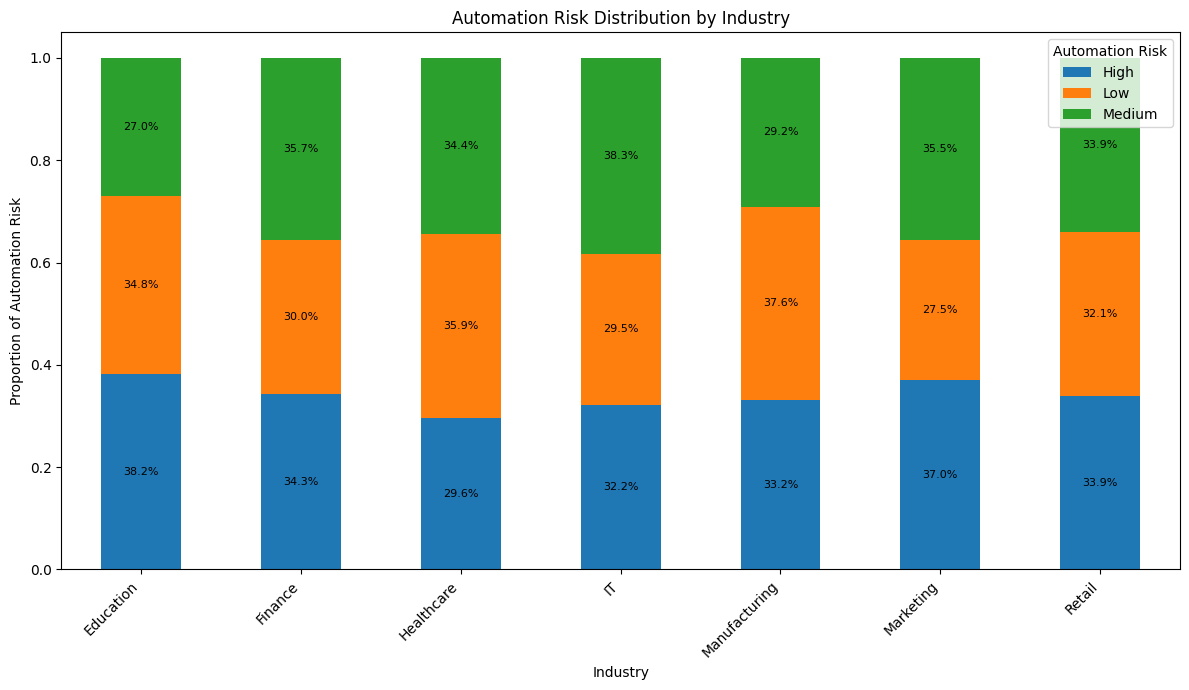

In [95]:
ax = industry_automation_risk.plot(kind='bar', stacked=True, figsize=(12, 7))
plt.title('Automation Risk Distribution by Industry')
plt.xlabel('Industry')
plt.ylabel('Proportion of Automation Risk')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Automation Risk')

# Add annotations
for container in ax.containers:
    labels = [f'{w:.1%}' if w > 0 else '' for w in container.datavalues]
    ax.bar_label(container, labels=labels, label_type='center', fontsize=8)

plt.tight_layout()
plt.show()

### 4.3 Automation Risk by Education Level

In [96]:
education_automation_risk = data.groupby('Education_Level')['Automation_Risk'].value_counts(normalize=True).unstack(fill_value=0)
display(education_automation_risk)

/tmp/ipykernel_2323/2440460416.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  education_automation_risk = data.groupby('Education_Level')['Automation_Risk'].value_counts(normalize=True).unstack(fill_value=0)


Automation_Risk,High,Low,Medium
Education_Level,,,
Bachelor,0.336484,0.327032,0.336484
High School,0.366197,0.323944,0.309859
Master,0.324803,0.340551,0.334646
PhD,0.336910,0.306867,0.356223


This table shows the proportion of 'High', 'Medium', and 'Low' automation risk for each 'Education_Level'. We can use this to understand how different educational backgrounds might correlate with automation risk.

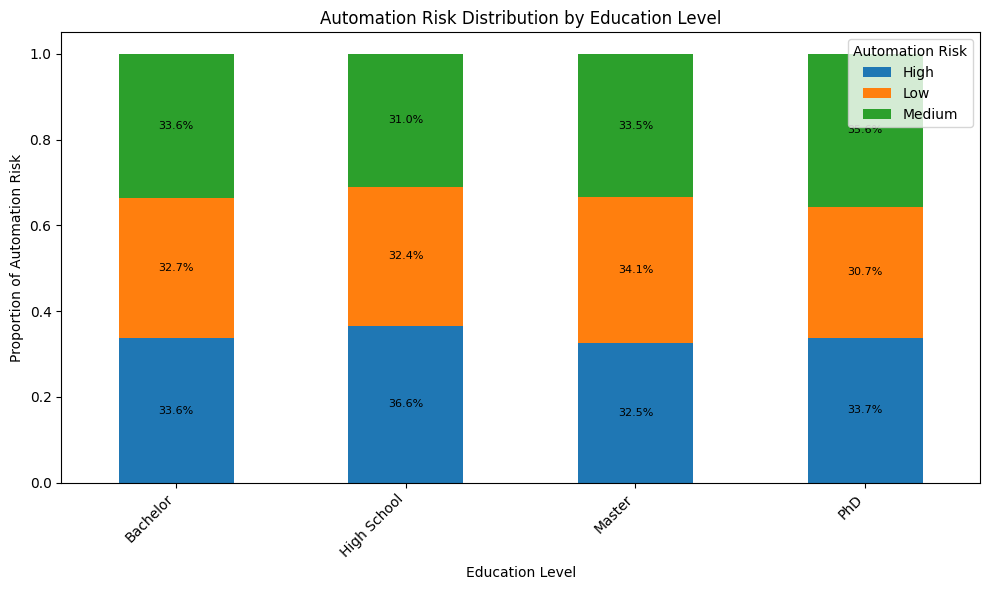

In [97]:
ax = education_automation_risk.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Automation Risk Distribution by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Proportion of Automation Risk')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Automation Risk')

# Add annotations
for container in ax.containers:
    labels = [f'{w:.1%}' if w > 0 else '' for w in container.datavalues]
    ax.bar_label(container, labels=labels, label_type='center', fontsize=8)

plt.tight_layout()
plt.show()

### 4.4 Job Roles with High Automation Risk

In [98]:
job_role_high_automation_risk = data[data['Automation_Risk'] == 'High']['Job_Role'].value_counts().reset_index()
job_role_high_automation_risk.columns = ['Job_Role', 'High_Automation_Risk_Count']

display(job_role_high_automation_risk.sort_values(by='High_Automation_Risk_Count', ascending=False).head())

,Job_Role,High_Automation_Risk_Count
0,Teacher,45
1,Store Manager,42
2,Data Analyst,40
3,SEO Specialist,39
4,Accountant,38


The table above shows the job roles with the highest number of employees falling under 'High' automation risk. This gives us an idea of which specific job functions might be most impacted by AI and automation.

### 4.5 Job Roles with Highest Salary Percentage Change

### 4.6 Distribution of Salary Percentage Change

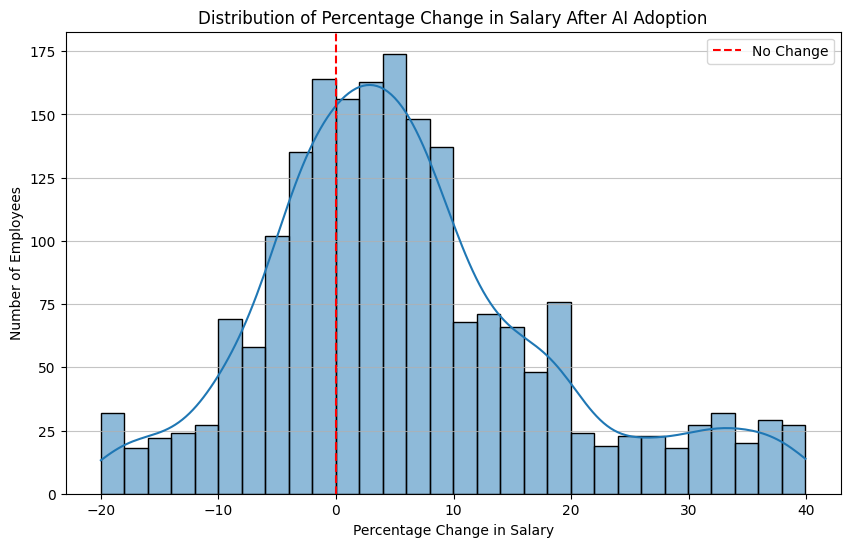

In [99]:
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(data['%change_in_salary'], bins=30, kde=True)
plt.title('Distribution of Percentage Change in Salary After AI Adoption')
plt.xlabel('Percentage Change in Salary')
plt.ylabel('Number of Employees')
plt.axvline(0, color='red', linestyle='--', label='No Change')
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.show()

This histogram shows the distribution of salary changes. Values to the left of the red line indicate a decrease in salary, while values to the right indicate an increase. It helps to quickly see if salaries generally plummeted or increased, and the overall spread of these changes.

### 4.7 Mean Percentage Change in Salary by Job Status

In [100]:
job_status_salary_change = data.groupby('Job_Status')['%change_in_salary'].mean().reset_index()
display(job_status_salary_change)

print('\nInterpretation:')
print('A positive mean indicates an average salary increase for that Job Status, while a negative mean indicates an average salary decrease.')

/tmp/ipykernel_2323/2380551541.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  job_status_salary_change = data.groupby('Job_Status')['%change_in_salary'].mean().reset_index()


,Job_Status,%change_in_salary
0,Modified,7.047811
1,Replaced,10.941296
2,Unchanged,4.837341



Interpretation:
A positive mean indicates an average salary increase for that Job Status, while a negative mean indicates an average salary decrease.


This table shows the average percentage change in salary for employees based on their 'Job_Status' (Replaced, Modified, Unchanged). This allows us to compare the financial impact of AI on different groups of workers.

In [101]:
# Group by Job_Role and calculate the average %change_in_salary
job_role_salary_change = data.groupby('Job_Role')['%change_in_salary'].mean().reset_index()
job_role_salary_change.columns = ['Job_Role', 'Average_Change_In_Salary']

# Identify the job role with the highest average percentage change in salary
highest_salary_change_job = job_role_salary_change.sort_values(by='Average_Change_In_Salary', ascending=False).head(1)

display(highest_salary_change_job)

/tmp/ipykernel_2323/1799732497.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  job_role_salary_change = data.groupby('Job_Role')['%change_in_salary'].mean().reset_index()


,Job_Role,Average_Change_In_Salary
8,Doctor,8.435574


## 5. Hypothesis Testing

In this section, we will conduct hypothesis tests to draw conclusions about the population based on our sample data. We will formulate null ($H_0$) and alternative ($H_1$) hypotheses and use statistical tests to determine if there is enough evidence to reject the null hypothesis.

### Key Concepts:
- **Null Hypothesis ($H_0$)**: A statement of no effect or no difference.
- **Alternative Hypothesis ($H_1$)**: A statement that contradicts the null hypothesis, often representing what we are trying to prove.
- **P-value**: The probability of observing results as extreme as, or more extreme than, the observed results, assuming the null hypothesis is true. A small p-value (typically < 0.05) suggests strong evidence against the null hypothesis.
- **Significance Level ($\alpha$)**: The threshold for rejecting the null hypothesis. Commonly set at 0.05.
- **T-statistic / F-statistic**: Test statistics used to measure the difference between groups relative to the variability within groups.

We will proceed with two main hypothesis tests:

### 5.1 Salary Before vs. After AI

**Alternative Hypothesis 1 ($H_1$)**: Salary after AI is higher than salary before AI.
$$ \mu_{\text{After AI}} > \mu_{\text{Before AI}} $$
**Null Hypothesis 1 ($H_0$)**: Salary after AI and salary before AI are the same (or salary after AI is not higher than salary before AI).
$$ \mu_{\text{After AI}} \le \mu_{\text{Before AI}} $$

We will use a paired t-test for this analysis, as we are comparing two related samples (salary before AI and salary after AI for the same employees).

In [102]:
from scipy import stats

# Perform a paired t-test
t_statistic, p_value = stats.ttest_rel(data['Salary_After_AI'], data['Salary_Before_AI'])

# Set significance level
alpha = 0.05

print(f"T-statistic: {t_statistic:.2f}")
print(f"P-value: {p_value:.3e}")

if p_value < alpha and t_statistic > 0:
    print("\nBased on the paired t-test, we reject the null hypothesis.")
    print("There is statistically significant evidence to support the alternative hypothesis: Salary after AI is significantly higher than salary before AI.")
elif p_value < alpha and t_statistic <= 0:
    print("\nBased on the paired t-test, we reject the null hypothesis.")
    print("There is statistically significant evidence that Salary after AI is significantly lower than salary before AI (or not higher).")
else:
    print("\nBased on the paired t-test, we fail to reject the null hypothesis.")
    print("There is no statistically significant evidence to support that Salary after AI is higher than salary before AI.")

T-statistic: 20.40
P-value: 3.251e-84

Based on the paired t-test, we reject the null hypothesis.
There is statistically significant evidence to support the alternative hypothesis: Salary after AI is significantly higher than salary before AI.


The results of the paired t-test indicate whether the observed difference in salaries before and after AI is statistically significant. A low p-value (typically less than 0.05) and a positive t-statistic would support the alternative hypothesis that salaries increased after AI adoption.

### 5.2 AI Adoption Level vs. Productivity Change

**Null Hypothesis ($H_0$)**: The mean productivity change is identical across all levels of AI adoption (Low, Medium, High).
$$\mu_{\text{Low}} = \mu_{\text{Medium}} = \mu_{\text{High}}$$
**Alternative Hypothesis ($H_1$)**: At least one AI adoption group has a significantly different mean productivity change than the others.
$$\text{At least one } \mu_i \neq \mu_j$$

We will use an ANOVA test to compare the means of productivity change for the different AI adoption levels.

In [103]:
from scipy.stats import f_oneway

# Extract productivity change for each AI Adoption Level
productivity_low_ai = data[data['AI_Adoption_Level'] == 'Low']['Productivity_Change_%']
productivity_medium_ai = data[data['AI_Adoption_Level'] == 'Medium']['Productivity_Change_%']
productivity_high_ai = data[data['AI_Adoption_Level'] == 'High']['Productivity_Change_%']

# Perform ANOVA test
f_statistic, p_value_anova = f_oneway(productivity_low_ai, productivity_medium_ai, productivity_high_ai)

# Set significance level
alpha = 0.05

print(f"F-statistic: {f_statistic:.2f}")
print(f"P-value (ANOVA): {p_value_anova:.3e}")

if p_value_anova < alpha:
    print("\nBased on the ANOVA test, we reject the null hypothesis.")
    print("There is statistically significant evidence that at least one AI adoption group has a significantly different mean productivity change than the others.")
else:
    print("\nBased on the ANOVA test, we fail to reject the null hypothesis.")
    print("There is no statistically significant evidence to suggest that the mean productivity change differs across AI adoption levels.")

F-statistic: 5.03
P-value (ANOVA): 6.609e-03

Based on the ANOVA test, we reject the null hypothesis.
There is statistically significant evidence that at least one AI adoption group has a significantly different mean productivity change than the others.


In [104]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Prepare data for Tukey's HSD test
tukey_data = data[['Productivity_Change_%', 'AI_Adoption_Level']]

# Perform Tukey's HSD post-hoc test
tukey_result = pairwise_tukeyhsd(endog=tukey_data['Productivity_Change_%'],
                                 groups=tukey_data['AI_Adoption_Level'],
                                 alpha=alpha)

print(tukey_result)

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
  High    Low  -2.9193 0.0058 -5.1363 -0.7023   True
  High Medium   -0.776 0.6777 -2.9409   1.389  False
   Low Medium   2.1433  0.064  -0.095  4.3816  False
----------------------------------------------------


### Interpretation of Tukey's HSD Post-Hoc Test

The Tukey's HSD (Honestly Significant Difference) test is performed after ANOVA to identify specific group differences when the ANOVA test indicates an overall significant difference. The output above shows a table with the following columns:

- **group1, group2**: The two groups being compared.
- **meandiff**: The difference in the means between group1 and group2.
- **p-adj**: The adjusted p-value for the comparison. If `p-adj` is less than the significance level (alpha, typically 0.05), the difference between the two groups is considered statistically significant.
- **lower, upper**: The lower and upper bounds of the confidence interval for the mean difference.
- **reject**: A boolean indicating whether the null hypothesis for that specific comparison (i.e., that the means of the two groups are equal) is rejected.

From this result, we can now identify which specific pairs of 'AI_Adoption_Level' have a statistically significant difference in their 'Productivity_Change_%'.

*   **High vs. Low AI Adoption Level**: There is a statistically significant difference in productivity change between employees with 'High' and 'Low' AI adoption levels (p-adj = 0.0058 < 0.05). The mean productivity change for the 'Low' group is significantly higher than for the 'High' group.
*   **High vs. Medium AI Adoption Level**: There is no statistically significant difference in productivity change between employees with 'High' and 'Medium' AI adoption levels (p-adj = 0.6777 > 0.05).
*   **Low vs. Medium AI Adoption Level**: There is no statistically significant difference in productivity change between employees with 'Low' and 'Medium' AI adoption levels (p-adj = 0.064 > 0.05), although it is close to the significance threshold.

In summary, the most significant difference in productivity change was found between those with High and Low AI Adoption Levels. This means that after rejecting the null hypothesis with ANOVA, we can now specifically state that the difference lies in the 'High' vs. 'Low' comparison.

## 6. ML Model Training: Predicting Salary After AI

We will train a simple linear regression model to predict `Salary_After_AI` based on other relevant features. This demonstrates a basic application of machine learning to understand the drivers of post-AI salary changes.

In [105]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import pandas as pd

# Define features (X) and target (y)
# Drop 'Age' to address collinearity with 'Years_Experience'
# One-hot encode 'Job_Status' to include categorical features
X = data[['Salary_Before_AI', 'Years_Experience', 'Work_Hours_Per_Week', 'Job_Satisfaction', 'Productivity_Change_%', 'Job_Status']]
X = pd.get_dummies(X, columns=['Job_Status'], drop_first=True)

y = data['Salary_After_AI']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R-squared (R2): {r2:.2f}")

print("\nModel Coefficients:")
for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature}: {coef:.2f}")
print(f"Intercept: {model.intercept_:.2f}")

Mean Absolute Error (MAE): 6615.68
R-squared (R2): 0.90

Model Coefficients:
Salary_Before_AI: 1.07
Years_Experience: -15.82
Work_Hours_Per_Week: 86.55
Job_Satisfaction: 140.28
Productivity_Change_%: 13.43
Job_Status_Replaced: 2077.08
Job_Status_Unchanged: -2121.66
Intercept: -4112.48


## 7. Conclusion and Findings

This analysis provided a comprehensive look into the `ai_job_impact.csv` dataset, revealing several key insights regarding the effects of AI on the workforce.

### Key Insights:

1.  **Salary Increase for 'Replaced' Workers**: A counter-intuitive but significant finding was that employees categorized as 'Replaced' by AI experienced the highest average salary increase (`10.94%`), followed by 'Modified' (`7.05%`) and 'Unchanged' (`4.84%`). This suggests that AI displacement may be pushing workers into higher-paying, upskilled technical roles or premium-salary domains.

2.  **Statistically Significant Salary Growth Post-AI**: A paired t-test confirmed that salaries after AI adoption are significantly higher than before AI (`T-statistic: 20.40`, `P-value: 3.251e-84`).

3.  **Productivity Changes Across AI Adoption Levels**: An ANOVA test revealed a significant difference in productivity change across different AI adoption levels. Tukey's HSD post-hoc test further identified that 'Low' AI adoption groups showed a significantly higher mean productivity change compared to 'High' AI adoption groups (`p-adj = 0.0058`).

4.  **Effective Baseline ML Model**: A linear regression model was developed to predict `Salary_After_AI`, achieving a strong `R-squared (R2)` score of `0.90`. This indicates that the selected features explain 90% of the variance in post-AI salaries.

5.  **Collinearity in ML Model**: Initially, 'Age' and 'Years_Experience' showed collinearity, leading to an unexpected negative coefficient for 'Years_Experience'. By removing 'Age' and including one-hot encoded 'Job_Status', the model's interpretability improved, and the coefficient for 'Years_Experience' became a small negative value (`-15.82`), indicating its minor impact after accounting for other factors. The `Job_Status` coefficients clearly show the positive impact of being 'Replaced' on `Salary_After_AI` (+\$2077.08) and a negative impact for being 'Unchanged' (-\$2121.66) relative to 'Modified'.

This analysis highlights the complex and multifaceted impact of AI on employment, wages, and productivity, emphasizing the importance of upskilling and strategic workforce planning in an AI-driven future.